In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [18]:
data=pd.read_csv('out.csv')
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,18
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11


In [3]:
data=data.sample(frac=1)

data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','C','O','H'],axis=1,inplace=True)
#data= data.set_index('Event')


data= data[data['Gas_Type'] != 'arnco2']
data.drop(['Gas_Type'],axis=1,inplace=True)

#data= data[data['Time_Window'] == 3]
#data.drop(['Time_Window'],axis=1,inplace=True)



data= data[data['Voltage'] == 5500]
#data= data[data['Voltage'] >= 5500]

#data.drop(['Voltage'],axis=1,inplace=True)


In [19]:
groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

Unnamed: 0  \
Gas_Type Detector_Size Cover_Size Voltage Time_Window Source                  
arnco2   6.78          4.78       2000    1           cs            60713.0   
                                                      kaynaksız     63309.0   
                                          3           cs            60804.0   
                                                      kaynaksız     63400.0   
                                          5           cs            60840.0   
...                                                                     ...   
p20      10.00         8.00       8000    10          kaynaksız     37024.0   
                                          15          cs            35619.0   
                                                      kaynaksız     37035.0   
                                          25          cs            35626.0   
                                                      kaynaksız     37042.0   

                                                                 CH4    Ar  \
Gas_Type Detector_Size Cover_Size Voltage Time_Window Source                 
arnco2   6.78          4.78       2000    1           cs         0.0  0.05   
                                                      kaynaksız  0.0  0.05   
                                          3           cs         0.0  0.05   
                                                      kaynaksız  0.0  0.05   
                                          5           cs         0.0  0.05   
...                                                              ...   ...   
p20      10.00         8.00       8000    10          kaynaksız  0.2  0.80   
                                          15          cs         0.2  0.80   
                                                      kaynaksız  0.2  0.80   
                                          25          cs         0.2  0.80   
                                                      kaynaksız  0.2  0.80   

                                                                   N2  CO2  \
Gas_Type Detector_Size Cover_Size Voltage Time_Window Source                 
arnco2   6.78          4.78       2000    1           cs         0.35  0.6   
                                                      kaynaksız  0.35  0.6   
                                          3           cs         0.35  0.6   
                                                      kaynaksız  0.35  0.6   
                                          5           cs         0.35  0.6   
...                                                               ...  ...   
p20      10.00         8.00       8000    10          kaynaksız  0.00  0.0   
                                          15          cs         0.00  0.0   
                                                      kaynaksız  0.00  0.0   
                                          25          cs         0.00  0.0   
                                                      kaynaksız  0.00  0.0   

                                                                    C    O  \
Gas_Type Detector_Size Cover_Size Voltage Time_Window Source                 
arnco2   6.78          4.78       2000    1           cs         0.20  0.4   
                                                      kaynaksız  0.20  0.4   
                                          3           cs         0.20  0.4   
                                                      kaynaksız  0.20  0.4   
                                          5           cs         0.20  0.4   
...                                                               ...  ...   
p20      10.00         8.00       8000    10          kaynaksız  0.04  0.0   
                                          15          cs         0.04  0.0   
                                                      kaynaksız  0.04  0.0   
                                          25          cs         0.04  0.0   
                                                      kaynaksız  0.04  

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3776 entries, 5266 to 37580
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               3776 non-null   float64
 1   Ar                3776 non-null   float64
 2   N2                3776 non-null   float64
 3   CO2               3776 non-null   float64
 4   Detector_Area     3776 non-null   float64
 5   Cover_Area        3776 non-null   float64
 6   Cover_Area_Ratio  3776 non-null   float64
 7   Voltage           3776 non-null   int64  
 8   Source            3776 non-null   object 
 9   Time_Window       3776 non-null   int64  
 10  Peak_Count        3776 non-null   int64  
dtypes: float64(7), int64(3), object(1)
memory usage: 354.0+ KB


In [5]:
data.isnull()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
5266,False,False,False,False,False,False,False,False,False,False,False
37726,False,False,False,False,False,False,False,False,False,False,False
35692,False,False,False,False,False,False,False,False,False,False,False
9899,False,False,False,False,False,False,False,False,False,False,False
23163,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
26857,False,False,False,False,False,False,False,False,False,False,False
23143,False,False,False,False,False,False,False,False,False,False,False
27343,False,False,False,False,False,False,False,False,False,False,False
27309,False,False,False,False,False,False,False,False,False,False,False


In [6]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
Detector_Area       0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

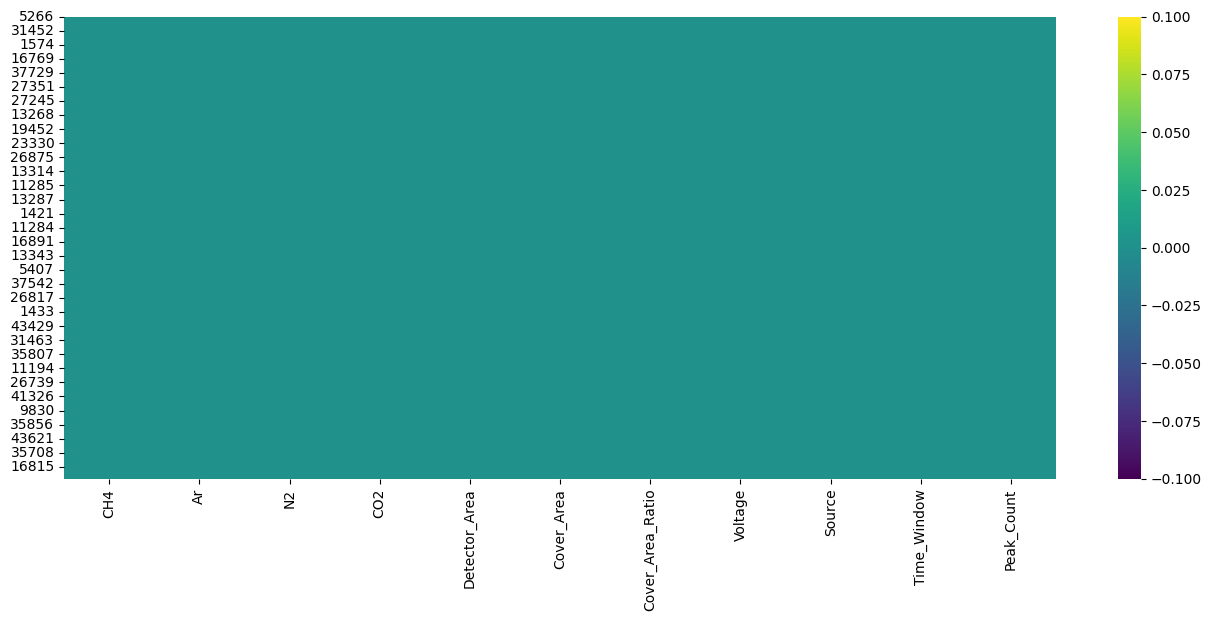

In [7]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [8]:
data.dropna(inplace=True)

In [9]:
data.isnull().sum()

CH4                 0
Ar                  0
N2                  0
CO2                 0
Detector_Area       0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [10]:
data.head()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
5266,0.1,0.9,0.0,0.0,100.00,36.00,0.36,5500,kaynaksız,1,8
37726,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5500,cs,10,182
35692,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5500,kaynaksız,1,21
9899,0.1,0.9,0.0,0.0,100.00,16.00,0.16,5500,cs,15,162
23163,0.1,0.9,0.0,0.0,45.97,44.62,0.97,5500,kaynaksız,1,3


In [11]:
type2=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type2

,kaynaksız
5266,1.0
37726,0.0
35692,1.0
9899,0.0
23163,1.0
...,...
26857,1.0
23143,1.0
27343,0.0
27309,0.0


In [12]:
type=pd.get_dummies(data['Source'],drop_first=True,dtype=float)
type

,kaynaksız
5266,1.0
37726,0.0
35692,1.0
9899,0.0
23163,1.0
...,...
26857,1.0
23143,1.0
27343,0.0
27309,0.0


In [13]:
data=pd.concat([data,type2],axis=1)
data.head()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,kaynaksız
5266,0.1,0.9,0.0,0.0,100.00,36.00,0.36,5500,kaynaksız,1,8,1.0
37726,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5500,cs,10,182,0.0
35692,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5500,kaynaksız,1,21,1.0
9899,0.1,0.9,0.0,0.0,100.00,16.00,0.16,5500,cs,15,162,0.0
23163,0.1,0.9,0.0,0.0,45.97,44.62,0.97,5500,kaynaksız,1,3,1.0


In [14]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [15]:
data.drop(['Source'],axis=1,inplace=True)
data.head()

,CH4,Ar,N2,CO2,Detector_Area,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,kaynaksız
5266,0.1,0.9,0.0,0.0,100.00,36.00,0.36,5500,1,8,1.0
37726,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5500,10,182,0.0
35692,0.2,0.8,0.0,0.0,100.00,64.00,0.64,5500,1,21,1.0
9899,0.1,0.9,0.0,0.0,100.00,16.00,0.16,5500,15,162,0.0
23163,0.1,0.9,0.0,0.0,45.97,44.62,0.97,5500,1,3,1.0


In [16]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3776 entries, 5266 to 37580
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CH4               3776 non-null   float64
 1   Ar                3776 non-null   float64
 2   N2                3776 non-null   float64
 3   CO2               3776 non-null   float64
 4   Detector_Area     3776 non-null   float64
 5   Cover_Area        3776 non-null   float64
 6   Cover_Area_Ratio  3776 non-null   float64
 7   Voltage           3776 non-null   int64  
 8   Time_Window       3776 non-null   int64  
 9   Peak_Count        3776 non-null   int64  
 10  kaynaksız         3776 non-null   float64
dtypes: float64(8), int64(3)
memory usage: 354.0 KB


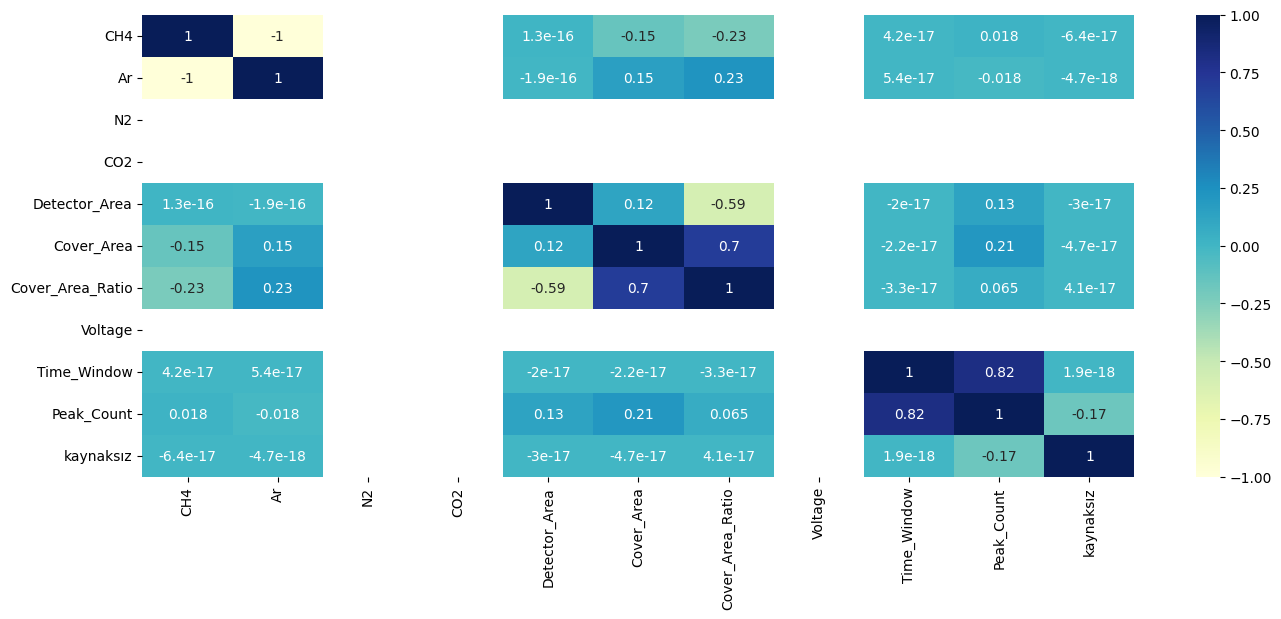

In [17]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [18]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['Detector_Area', 'Cover_Area', 'Time_Window', 'Peak_Count', 'kaynaksız']

In [19]:
data=data[list(corr.index)]
data

,Detector_Area,Cover_Area,Time_Window,Peak_Count,kaynaksız
5266,100.00,36.00,1,8,1.0
37726,100.00,64.00,10,182,0.0
35692,100.00,64.00,1,21,1.0
9899,100.00,16.00,15,162,0.0
23163,45.97,44.62,1,3,1.0
...,...,...,...,...,...
26857,100.00,36.00,5,81,1.0
23143,45.97,44.62,1,8,1.0
27343,100.00,36.00,10,260,0.0
27309,100.00,36.00,3,72,0.0


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,Detector_Area,Cover_Area,Time_Window,kaynaksız
5266,100.00,36.00,1,1.0
37726,100.00,64.00,10,0.0
35692,100.00,64.00,1,1.0
9899,100.00,16.00,15,0.0
23163,45.97,44.62,1,1.0


In [22]:
y=data['Peak_Count']
y

5266       8
37726    182
35692     21
9899     162
23163      3
        ... 
26857     81
23143      8
27343    260
27309     72
37580     18
Name: Peak_Count, Length: 3776, dtype: int64

In [23]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model=LinearRegression()

In [26]:
model.fit(X_train,y_train)

LinearRegression()

In [27]:
pred=model.predict(X_test)
pred

array([ 50.15579444,  39.91246633, 151.02826003,  16.47726541,
        26.72059353,   3.28539261,  26.02894756,  26.02894756,
        26.02894756,  35.50635678, 128.28470509, -10.67239908,
       -10.67239908, -10.67239908,  12.07115587, -10.67239908,
         3.28539261,  -6.9579355 , 293.29356682,  12.76280183,
        12.07115587, -10.67239908,  15.78561945,   3.28539261,
        69.00505684, 304.04871194,  62.65602127,   3.28539261,
        12.07115587,   3.28539261,  26.72059353,  49.46414847,
       -10.67239908, 157.08847089, -22.15099175,   0.59256319,
        22.82630098,  22.82630098,   0.59256319,  69.00505684,
       164.63896958, 304.04871194,  26.72059353, -10.67239908,
       141.89541464,  26.02894756, 121.24402356,  45.56985593,
        15.78561945,  47.46296502, -10.67239908,  26.02894756,
       108.74379672,   0.59256319, -22.15099175, 179.83202584,
        -6.9579355 ,  12.76280183,  26.02894756,  58.94155769,
       -10.67239908,  22.82630098,  72.89934938,  12.76

In [28]:
y_test

5376      43
23304     29
13428    239
23279     22
5368      20
        ... 
34156     31
37691     63
13401    119
11171      7
1565      58
Name: Peak_Count, Length: 756, dtype: int64

In [29]:
X_test

,Detector_Area,Cover_Area,Time_Window,kaynaksız
5376,100.00,36.00,5,1.0
23304,45.97,44.62,5,1.0
13428,100.00,64.00,10,0.0
23279,45.97,44.62,3,1.0
5368,100.00,36.00,3,1.0
...,...,...,...,...
34156,100.00,16.00,3,0.0
37691,100.00,64.00,3,0.0
13401,100.00,64.00,5,0.0
11171,100.00,16.00,1,1.0


In [30]:
model.score(X_test, y_test)

0.7327263161822023

In [31]:
pred

array([ 50.15579444,  39.91246633, 151.02826003,  16.47726541,
        26.72059353,   3.28539261,  26.02894756,  26.02894756,
        26.02894756,  35.50635678, 128.28470509, -10.67239908,
       -10.67239908, -10.67239908,  12.07115587, -10.67239908,
         3.28539261,  -6.9579355 , 293.29356682,  12.76280183,
        12.07115587, -10.67239908,  15.78561945,   3.28539261,
        69.00505684, 304.04871194,  62.65602127,   3.28539261,
        12.07115587,   3.28539261,  26.72059353,  49.46414847,
       -10.67239908, 157.08847089, -22.15099175,   0.59256319,
        22.82630098,  22.82630098,   0.59256319,  69.00505684,
       164.63896958, 304.04871194,  26.72059353, -10.67239908,
       141.89541464,  26.02894756, 121.24402356,  45.56985593,
        15.78561945,  47.46296502, -10.67239908,  26.02894756,
       108.74379672,   0.59256319, -22.15099175, 179.83202584,
        -6.9579355 ,  12.76280183,  26.02894756,  58.94155769,
       -10.67239908,  22.82630098,  72.89934938,  12.76

In [32]:
y_test

5376      43
23304     29
13428    239
23279     22
5368      20
        ... 
34156     31
37691     63
13401    119
11171      7
1565      58
Name: Peak_Count, Length: 756, dtype: int64

In [33]:
indexes = X_test.index.values
len(indexes)

756

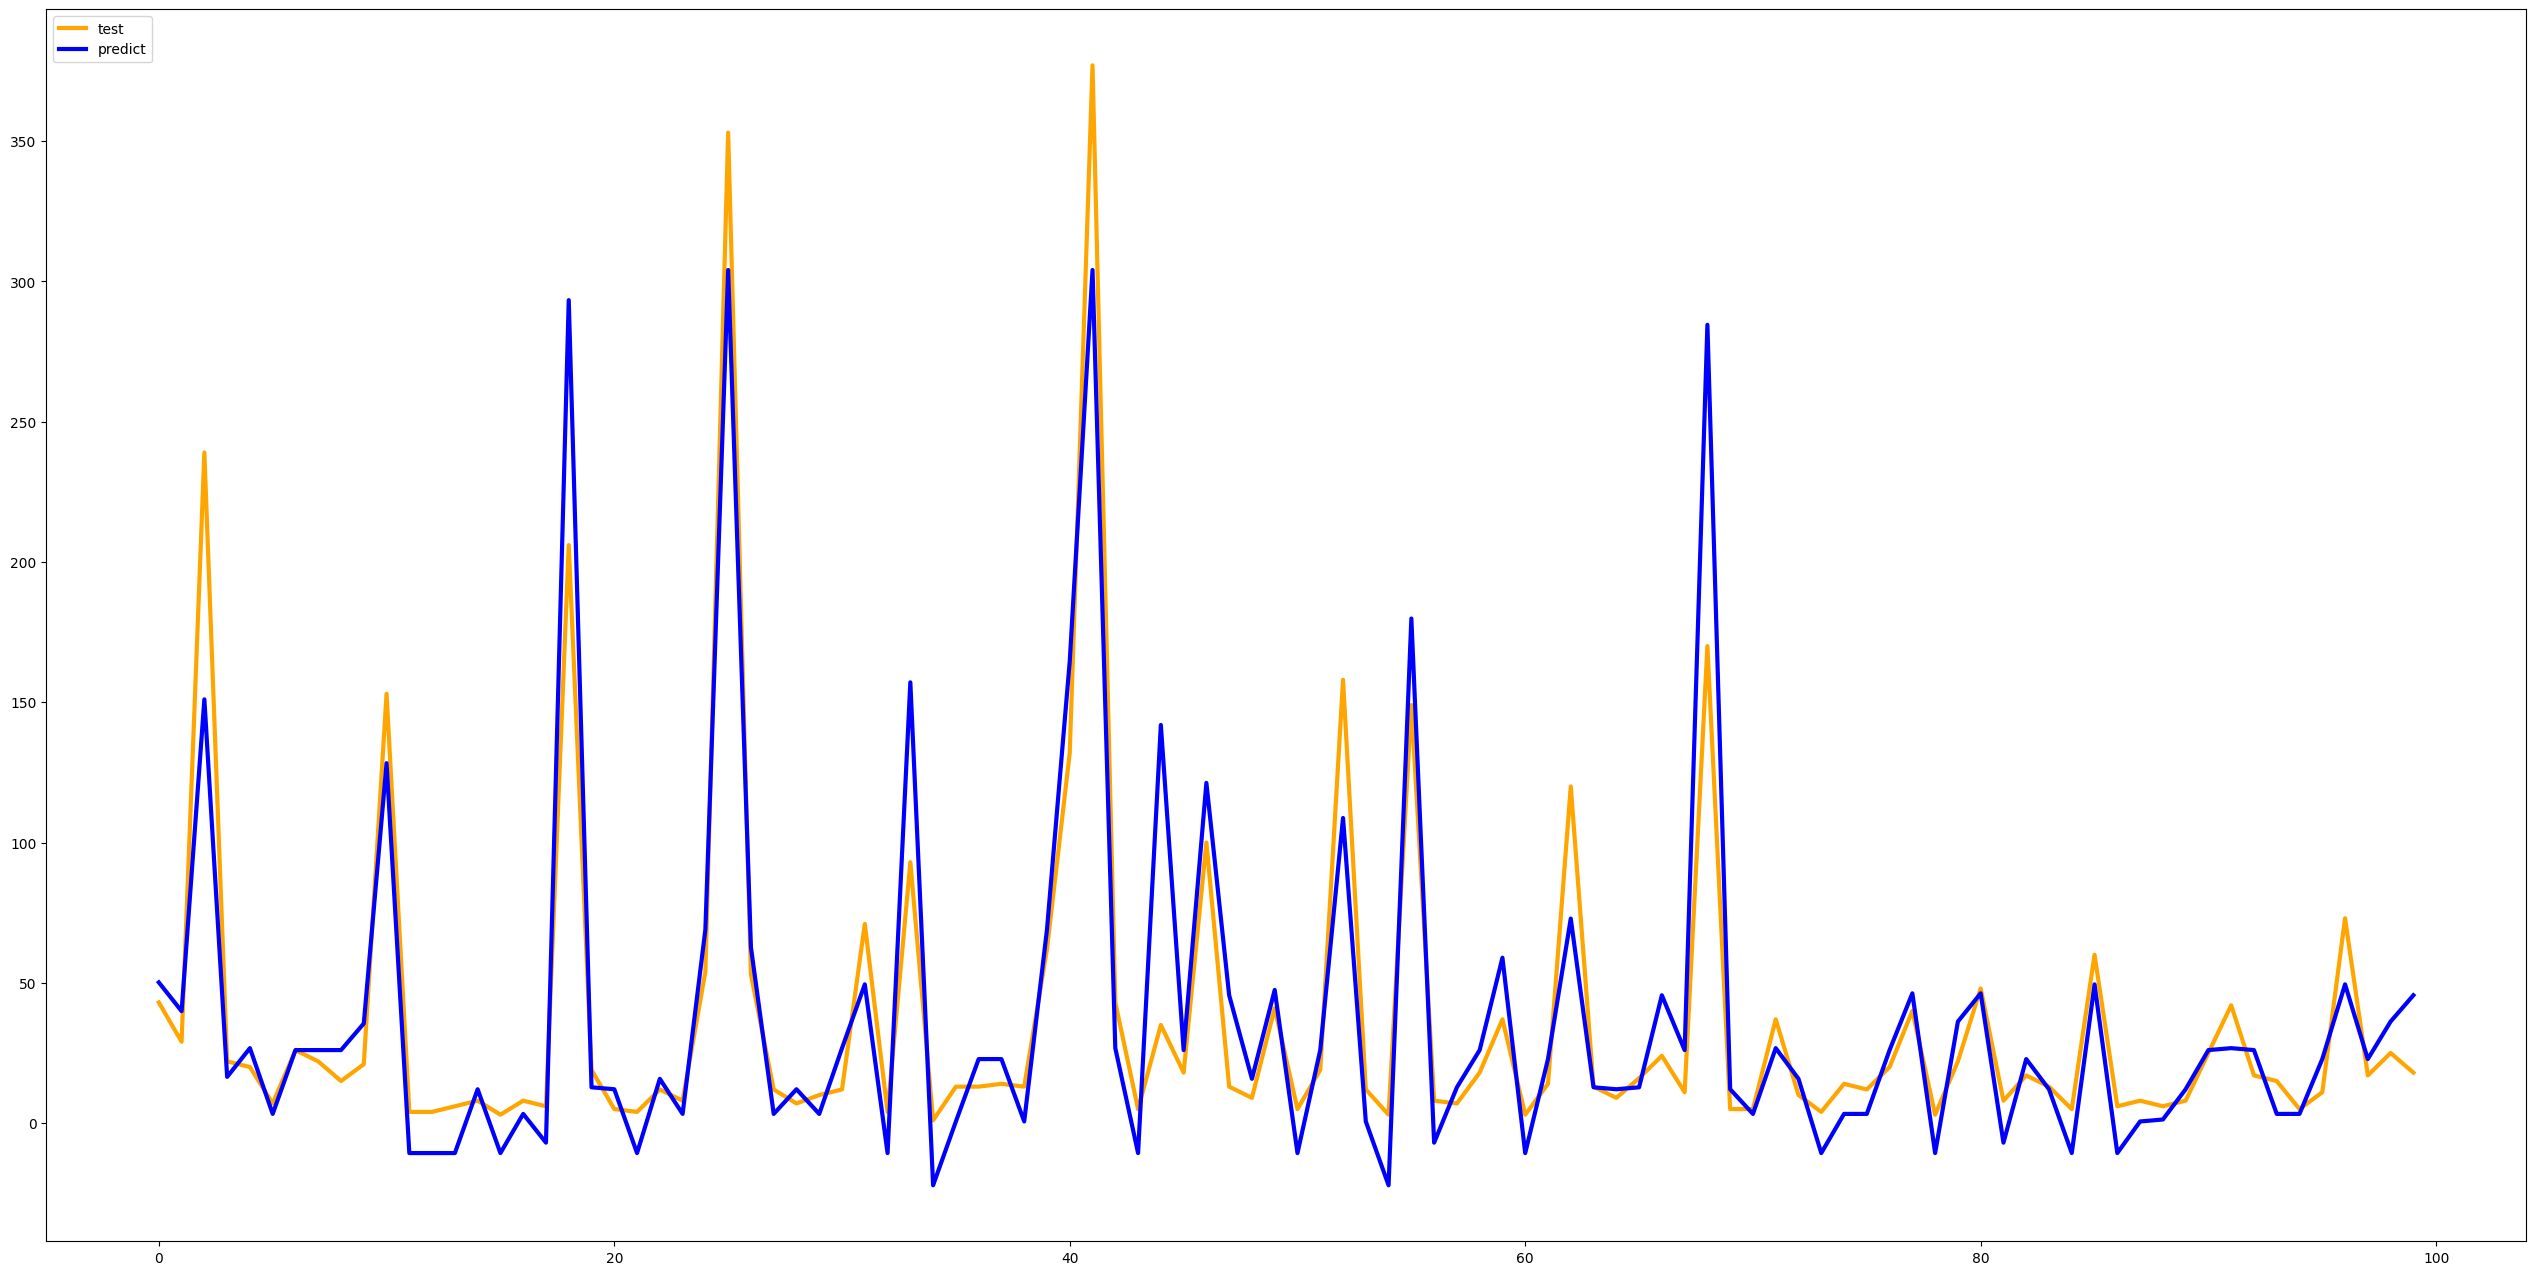

In [34]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()